# **LOAD DATA**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
df ='/content/drive/MyDrive/DATA/skripsi/data/fetal_health.csv'
df = pd.read_csv(df)
df

Mounted at /content/drive


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


In [2]:
# Ganti nama kolom yang spesifik
df= df.rename(columns={
    'abnormal_short_term_variability': 'abnormal STV',
    'mean_value_of_short_term_variability': 'mean STV',
    'percentage_of_time_with_abnormal_long_term_variability': 'percentage ALTV',
    'mean_value_of_long_term_variability': 'mean LTV'
})

# Lanjutkan dengan pengolahan selanjutnya seperti plot atau analisis

# Asumsikan variabel df sudah ada sebelumnya, kita akan membuat variabel 'data' baru
data = df.copy()  # Salin data dari df ke variabel baru 'data'

# Buat list baru untuk kolom x1 hingga x21 dan fetal_health
new_columns = ['x' + str(i) for i in range(1, 22)] + ['fetal_health']

# Ganti nama kolom data dengan new_columns
data.columns = new_columns

# Tampilkan beberapa data untuk verifikasi
print(data.head())


      x1     x2   x3     x4     x5   x6   x7    x8   x9   x10  ...   x13  \
0  120.0  0.000  0.0  0.000  0.000  0.0  0.0  73.0  0.5  43.0  ...  62.0   
1  132.0  0.006  0.0  0.006  0.003  0.0  0.0  17.0  2.1   0.0  ...  68.0   
2  133.0  0.003  0.0  0.008  0.003  0.0  0.0  16.0  2.1   0.0  ...  68.0   
3  134.0  0.003  0.0  0.008  0.003  0.0  0.0  16.0  2.4   0.0  ...  53.0   
4  132.0  0.007  0.0  0.008  0.000  0.0  0.0  16.0  2.4   0.0  ...  53.0   

     x14   x15  x16    x17    x18    x19   x20  x21  fetal_health  
0  126.0   2.0  0.0  120.0  137.0  121.0  73.0  1.0           2.0  
1  198.0   6.0  1.0  141.0  136.0  140.0  12.0  0.0           1.0  
2  198.0   5.0  1.0  141.0  135.0  138.0  13.0  0.0           1.0  
3  170.0  11.0  0.0  137.0  134.0  137.0  13.0  1.0           1.0  
4  170.0   9.0  0.0  137.0  136.0  138.0  11.0  1.0           1.0  

[5 rows x 22 columns]


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   x1            2126 non-null   float64
 1   x2            2126 non-null   float64
 2   x3            2126 non-null   float64
 3   x4            2126 non-null   float64
 4   x5            2126 non-null   float64
 5   x6            2126 non-null   float64
 6   x7            2126 non-null   float64
 7   x8            2126 non-null   float64
 8   x9            2126 non-null   float64
 9   x10           2126 non-null   float64
 10  x11           2126 non-null   float64
 11  x12           2126 non-null   float64
 12  x13           2126 non-null   float64
 13  x14           2126 non-null   float64
 14  x15           2126 non-null   float64
 15  x16           2126 non-null   float64
 16  x17           2126 non-null   float64
 17  x18           2126 non-null   float64
 18  x19           2126 non-null 

<Axes: >

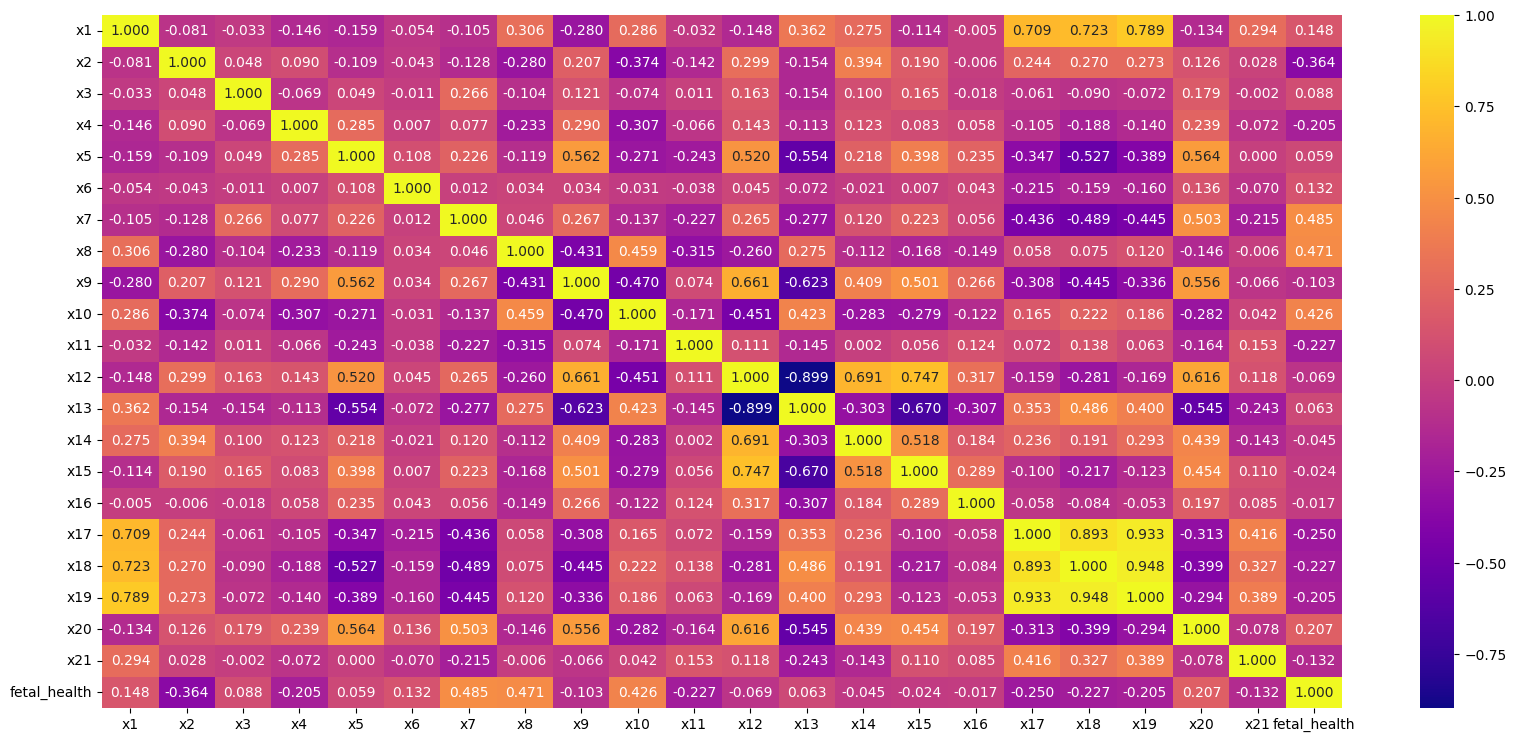

In [4]:
#melihat multiko jika korelasi diatas 0.6
plt.figure(figsize=(20,9))
sns.heatmap(data.corr(), annot = True, fmt = '.3f', cmap = 'plasma')

In [21]:
x = data.drop(['fetal_health'], axis=1)
y = data['fetal_health']
print(y.value_counts())
y_target= y.map({1: 0, 2: 1, 3: 2}).astype(int)
print(y_target.value_counts())

fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64
fetal_health
0    1655
1     295
2     176
Name: count, dtype: int64


# **ISOLATION FOREST**

In [22]:
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import IsolationForest

# Inisialisasi Isolation Forest dengan parameter yang ditentukan
iso_forest = IsolationForest(
    n_estimators=100,
    max_samples=1.0,
    contamination=0.05,
    max_features=1.0,
    bootstrap=False,
    n_jobs=None,
    random_state=42
)

# Mengukur waktu pelatihan
start_time = time.time()
iso_forest.fit(x)  # Melatih model pada data
training_time = time.time() - start_time

# Mengukur waktu prediksi
start_time = time.time()
scores = iso_forest.decision_function(x)  # Menghitung skor untuk setiap sampel
prediction_time = time.time() - start_time

# Mendapatkan panjang lintasan (path length) untuk masing-masing pohon
path_lengths = np.zeros((x.shape[0], len(iso_forest.estimators_)))

for i, tree in enumerate(iso_forest.estimators_):
    decision_path = tree.decision_path(x)
    path_lengths[:, i] = decision_path.sum(axis=1).A1 - 1  # Konversi ke array 1D

# Menghitung rata-rata panjang lintasan untuk setiap sampel
avg_path_length = path_lengths.mean(axis=1)

# Menambahkan kolom baru ke data untuk skor dan rata-rata path length
data['IsolationForest_Score'] = scores
data['Avg_Path_Length'] = avg_path_length

# Menyimpan urutan indeks asli sebelum pengurutan
data['Original_Index'] = data.index + 1  # Indeks asli dimulai dari 1
data['y'] = y

# Fungsi untuk menghitung c(n)
def c(n):
    if n > 2:
        return 2 * (np.log(n - 1) + 0.5772156649) - 2 * (n - 1) / n
    elif n == 2:
        return 1
    else:
        return 0

# Menghitung c(n) untuk dataset
n = data.shape[0]
c_n = c(n)

# Menghitung skor manual berdasarkan rumus manual Isolation Forest
data['Skor_Manual'] = 2 ** (-data['Avg_Path_Length'] / c_n)

# Menentukan threshold untuk outliers berdasarkan contamination
contamination = 0.05
n_outliers = int(contamination * n)

# Menambahkan kolom 'Outlier_Flag' sebelum pengurutan
data['Outlier_Flag'] = 1  # Default sebagai inlier
data.loc[data['Skor_Manual'].nlargest(n_outliers).index, 'Outlier_Flag'] = -1  # Label outlier

# Membuat salinan data asli untuk referensi urutan awal sebelum pengurutan
data_original = data.copy()

# Mengurutkan data berdasarkan skor manual (descending order)
data_sorted = data.sort_values(by='Skor_Manual', ascending=False).reset_index(drop=True)

# Memisahkan data ke dalam dua bagian: outlier dan inlier
outliers_data = data_sorted[data_sorted['Outlier_Flag'] == -1].reset_index(drop=True)
inliers_data = data_sorted[data_sorted['Outlier_Flag'] == 1].reset_index(drop=True)

# Membuat tabel path length untuk setiap tree dan menambahkan average path length, y, dan original index
path_length_df = pd.DataFrame(path_lengths, columns=[f'Path_Length_Tree_{i+1}' for i in range(len(iso_forest.estimators_))])
path_length_df['Avg_Path_Length'] = avg_path_length
path_length_df['Original_Index'] = data_original['Original_Index']  # Urutan asli data tetap dipertahankan
path_length_df['y'] = data_original['y']  # Tambahkan kolom y

# Membuat tabel untuk data asli yang berisi kolom: index, original_index, x, y, avg_path_length, skor, label, skor manual, label manual
data_original['Manual_Label'] = data_original['Outlier_Flag']
data_to_save = data_original[['Original_Index'] + list(x.columns) + ['y', 'Avg_Path_Length', 'IsolationForest_Score', 'Outlier_Flag', 'Skor_Manual', 'Manual_Label']]

# Menyimpan data ke file Excel dengan empat sheet: Data Asli, Outliers, Inliers, dan Path Lengths
with pd.ExcelWriter('if_manual_urutan_all.xlsx') as writer:
    data_to_save.to_excel(writer, sheet_name='Original_Data', index=False)
    outliers_data[['Original_Index'] + list(x.columns) + ['y', 'Avg_Path_Length', 'IsolationForest_Score', 'Skor_Manual', 'Outlier_Flag']].to_excel(writer, sheet_name='Outliers', index=False)
    inliers_data[['Original_Index'] + list(x.columns) + ['y', 'Avg_Path_Length', 'IsolationForest_Score', 'Skor_Manual', 'Outlier_Flag']].to_excel(writer, sheet_name='Inliers', index=False)
    path_length_df.to_excel(writer, sheet_name='Path_Lengths', index=False)

print("Data berhasil disimpan ke dalam file Excel 'if_manual_urutan_all.xlsx' dengan skor manual, urutan data asli, dan variabel target y.")

# Menampilkan beberapa nilai skor manual untuk data outliers
print("Beberapa nilai skor manual untuk data outliers:")
print(outliers_data[['IsolationForest_Score', 'Avg_Path_Length', 'Skor_Manual']].head())

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warning

Data berhasil disimpan ke dalam file Excel 'if_manual_urutan_all.xlsx' dengan skor manual, urutan data asli, dan variabel target y.
Beberapa nilai skor manual untuk data outliers:
   IsolationForest_Score  Avg_Path_Length  Skor_Manual
0              -0.180142             7.32     0.704377
1              -0.152081             8.04     0.680511
2              -0.139704             8.41     0.668563
3              -0.133428             8.42     0.668243
4              -0.116793             8.49     0.666007


In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Fungsi untuk plot dan simpan pohon
def save_plot_tree(iso_forest, tree_index, x_columns, filename):
    # Ambil estimator (tree) berdasarkan index
    tree = iso_forest.estimators_[tree_index]

    # Plot tree dengan node_ids untuk menggantikan label nanti
    plt.figure(figsize=(350, 30))
    plot_tree(tree, filled=False, feature_names=x_columns, rounded=True, fontsize=12, node_ids=True)
    plt.title(f"Pohon Ke-{tree_index + 1} Isolation Forest", fontsize=20)  # Indeks +1 untuk plot

    # Mengambil sumbu plot saat ini
    ax = plt.gca()

    # Iterasi setiap teks di pohon untuk mengganti 'value =', 'squared_error', dan 'samples ='
    for text in ax.texts:
        new_text = text.get_text()

        # Hilangkan 'value =', 'squared_error', dan 'samples ='
        for term in ['value =', 'squared_error', 'n_samples =']:
            if term in new_text:
                parts = new_text.split('\n')
                parts = [line for line in parts if term not in line]
                new_text = "\n".join(parts)

        # Tetapkan teks yang baru tanpa 'value =', 'squared_error', dan 'samples ='
        text.set_text(new_text)

    # Simpan plot ke file
    plt.savefig(filename)
    plt.close()

# Plot dan simpan pohon ke-1, ke-2, dan ke-100 (diambil dari tree_index 0, 1, 99)
save_plot_tree(iso_forest, 0, x.columns, 'pohon1_if.png')
save_plot_tree(iso_forest, 1, x.columns, 'pohon2_if.png')
save_plot_tree(iso_forest, 99, x.columns, 'pohon100_if.png')


# **PLOTING**

In [13]:
print(data.columns[0:21])
print(inliers_data.columns[0:21])

Index(['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11',
       'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21'],
      dtype='object')
Index(['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11',
       'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21'],
      dtype='object')


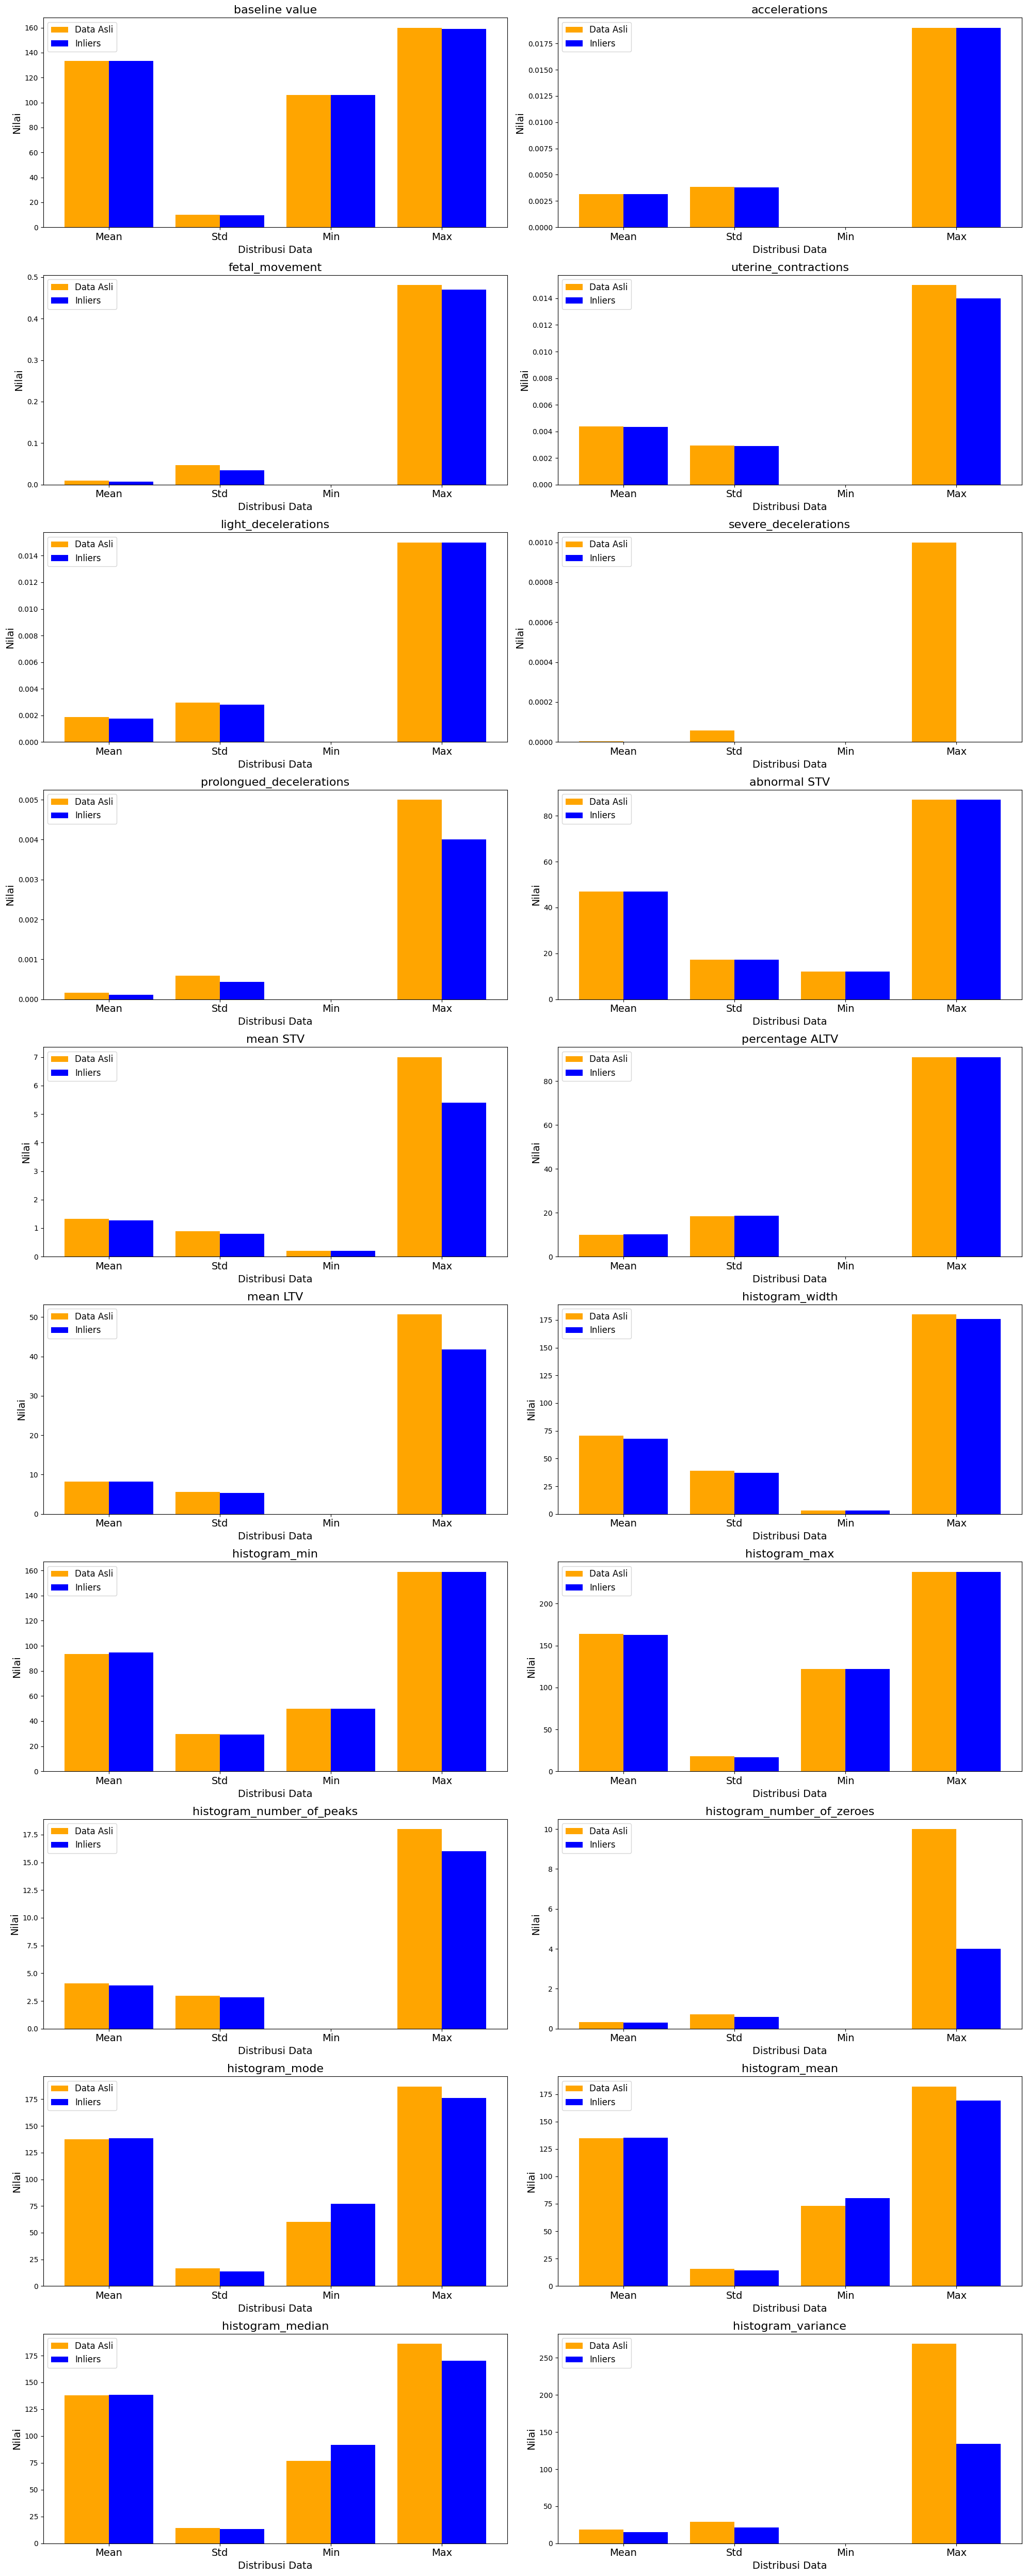

Data summary statistik berhasil disimpan ke file 'summary_statistics.xlsx'.


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Variabel asli dari df
original_variables = df.columns[:21]  # Ambil nama variabel asli dari kolom pertama hingga ke-21

# Mengambil variabel dari kolom ke-3 hingga ke-22
variables_data = data.columns[0:20]
variables_inliers = inliers_data.columns[0:20]

# Menghitung mean, std, min, dan max untuk data asli dan inliers
mean_data = data[variables_data].mean()
mean_inliers = inliers_data[variables_inliers].mean()

std_data = data[variables_data].std()
std_inliers = inliers_data[variables_inliers].std()

min_data = data[variables_data].min()
min_inliers = inliers_data[variables_inliers].min()

max_data = data[variables_data].max()
max_inliers = inliers_data[variables_inliers].max()

mode_data = data[variables_data].mode().iloc[0]  # Ambil modus pertama
mode_inliers = inliers_data[variables_inliers].mode().iloc[0]  # Ambil modus pertama

# Mengatur jumlah baris untuk 2 kolom
n_variables = len(variables_data)
n_cols = 2
n_rows = (n_variables + n_cols - 1) // n_cols  # Hitung jumlah baris

# Mengatur subplot dengan 2 kolom
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))

# Loop untuk setiap variabel
for i, variable in enumerate(variables_data):
    row = i // n_cols
    col = i % n_cols

    ax = axes[row, col]

    # Plot mean, std, min, max, dan mode
    ax.bar([0, 1, 2, 3],
           [mean_data[variable], std_data[variable], min_data[variable], max_data[variable]],
           width=0.4, label='Data Asli', color='orange')
    ax.bar([0.4, 1.4, 2.4, 3.4],
           [mean_inliers[variable], std_inliers[variable], min_inliers[variable], max_inliers[variable]],
           width=0.4, label='Inliers', color='blue')

    # Mengatur ticks dan labels
    ax.set_xticks([0.2, 1.2, 2.2, 3.2])
    ax.set_xticklabels(['Mean', 'Std', 'Min', 'Max'], fontsize=14)
    ax.set_title(original_variables[i], fontsize=16)
    ax.set_xlabel('Distribusi Data', fontsize=14)  # Tambahkan xlabel
    ax.set_ylabel('Nilai', fontsize=14)  # Tambahkan ylabel
    ax.legend(fontsize=12)

# Hapus subplot kosong jika ada
if n_variables < n_rows * n_cols:
    for i in range(n_variables, n_rows * n_cols):
        fig.delaxes(axes.flatten()[i])

# Menyesuaikan layout
plt.tight_layout()

# Simpan gambar sebagai file PNG
plt.savefig('barplot_summary_2col.png', dpi=300)

# Tampilkan plot
plt.show()

# Membuat summary statistik untuk data asli dan inliers
summary_stats_data = pd.DataFrame({
    'Variable': variables_data,
    'Mean_Data': mean_data.values,
    'Mean_Inliers': mean_inliers.values,
    'Std_Data': std_data.values,
    'Std_Inliers': std_inliers.values,
    'Min_Data': min_data.values,
    'Min_Inliers': min_inliers.values,
    'Max_Data': max_data.values,
    'Max_Inliers': max_inliers.values,
    'Mode_Data': mode_data.values,
    'Mode_Inliers': mode_inliers.values
})

# Menyimpan summary statistik ke dalam file Excel
summary_stats_data.to_excel('summary_statistics.xlsx', index=False)

print("Data summary statistik berhasil disimpan ke file 'summary_statistics.xlsx'.")


**PLOTING**

In [ ]:
# Variabel asli dari df
original_variables = df.columns[:21]  # Ambil nama variabel asli dari kolom pertama hingga ke-21

# Variabel untuk subplot (ambil dari kolom pertama hingga ke-21 untuk 'data', dan dari kolom ketiga hingga ke-24 untuk 'inliers_data')
variables_data = data.columns[1:22]  # Ambil kolom pertama hingga ke-21 dari data
variables_inliers = inliers_data.columns[2:23]  # Ambil kolom ketiga hingga ke-24 dari inliers_data

num_vars = len(variables_data)  # Tetap menghitung berdasarkan variabel data

# Menghitung jumlah baris dan kolom yang dibutuhkan
n_cols = 7
n_rows = (num_vars // n_cols) + (1 if num_vars % n_cols != 0 else 0)

# Mengatur subplot sesuai dengan jumlah baris dan kolom
fig, axes = plt.subplots(n_rows, n_cols, figsize=(21, n_rows * 3))
axes = axes.flatten()  # Rata baris dan kolom menjadi satu dimensi

# Menggambar plot untuk setiap variabel (data dari kolom pertama hingga ke-21, inliers dari kolom ketiga hingga ke-24)
for i, var in enumerate(variables_data):
    sns.histplot(data[var], ax=axes[i], color='blue', label='Data Asli', alpha=0.5)
    if i < len(variables_inliers):  # Hanya tampilkan inliers jika ada variabel yang sesuai
        sns.histplot(inliers_data[variables_inliers[i]], ax=axes[i], color='red', label='Inliers', alpha=0.5)

    # Menggunakan nama variabel asli dari df sebagai judul
    axes[i].set_title(original_variables[i])
    axes[i].set_ylabel("Frekuensi")  # Menambahkan label sumbu y sebagai "Frekuensi"
    axes[i].legend()

# Hapus subplot kosong jika ada
for i in range(num_vars, len(axes)):
    fig.delaxes(axes[i])

# Menyesuaikan layout
plt.tight_layout()

# Simpan gambar sebagai file PNG
plt.savefig('subplot_if.png', dpi=300)
plt.show()


In [ ]:
# Menghitung frekuensi untuk setiap variabel
frequencies_data = {var: data[var].value_counts().sort_index() for var in variables_data}
frequencies_inliers = {var: inliers_data[variables_inliers[i]].value_counts().sort_index() for i, var in enumerate(variables_data)}

# Mengatur subplot sesuai dengan jumlah baris dan kolom
fig, axes = plt.subplots(n_rows, n_cols, figsize=(21, n_rows * 3))
axes = axes.flatten()  # Rata baris dan kolom menjadi satu dimensi

# Menggambar line plot untuk setiap variabel
for i, var in enumerate(variables_data):
    # Plot data asli
    sns.lineplot(x=frequencies_data[var].index, y=frequencies_data[var].values, ax=axes[i], color='blue', label='Data Asli')

    # Plot inliers
    if i < len(variables_inliers):  # Hanya tampilkan inliers jika ada variabel yang sesuai
        sns.lineplot(x=frequencies_inliers[variables_inliers[i]].index, y=frequencies_inliers[variables_inliers[i]].values, ax=axes[i], color='red', label='Inliers')

    # Menggunakan nama variabel asli dari df sebagai judul
    axes[i].set_title(original_variables[i])
    axes[i].set_ylabel("Frekuensi")  # Menambahkan label sumbu y sebagai "Frekuensi"
    axes[i].legend()

# Hapus subplot kosong jika ada
for i in range(num_vars, len(axes)):
    fig.delaxes(axes[i])

# Menyesuaikan layout
plt.tight_layout()

# Simpan gambar sebagai file PNG
plt.savefig('subplot_if_lineplot.png', dpi=300)
plt.show()


In [ ]:
# inliers_data.columns[2]
data.columns[0]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur ukuran plot
plt.figure(figsize=(10, 6))

# Membuat scatter plot untuk data asli
sns.scatterplot(x=data[data.columns[2]], y=data[data.columns[3]], color='blue', label='Data Asli', alpha=0.6)

# Membuat scatter plot untuk data inliers
sns.scatterplot(x=inliers_data[inliers_data.columns[2]], y=inliers_data[inliers_data.columns[3]], color='yellow', label='Inliers', alpha=0.6)

# Menambahkan judul dan label
plt.title('Scatter Plot Variabel Pertama')
plt.xlabel('Variabel Pertama')
plt.ylabel('Index')  # Menggunakan indeks sebagai sumbu y
plt.legend()
plt.tight_layout()

# Simpan gambar sebagai file PNG
plt.savefig('scatter_plot_variabel_pertama.png', dpi=300)

# Tampilkan plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Mengambil variabel dari kolom ke-3 hingga ke-24
variables_data = data.columns[2:23]
variables_inliers = inliers_data.columns[2:23]

# Menghitung mean, std, min, dan max untuk data asli dan inliers
mean_data = data[variables_data].mean()
mean_inliers = inliers_data[variables_inliers].mean()

std_data = data[variables_data].std()
std_inliers = inliers_data[variables_inliers].std()

min_data = data[variables_data].min()
min_inliers = inliers_data[variables_inliers].min()

max_data = data[variables_data].max()
max_inliers = inliers_data[variables_inliers].max()

# Mengatur subplot dengan 4 baris
fig, axes = plt.subplots(4, 1, figsize=(15, 20))

# Baris 1: Mean
axes[0].bar(np.arange(len(variables_data)) - 0.2, mean_data, width=0.4, label='Data Asli', color='blue')
axes[0].bar(np.arange(len(variables_inliers)) + 0.2, mean_inliers, width=0.4, label='Inliers', color='orange')
axes[0].set_xticks(np.arange(len(variables_data)))
axes[0].set_xticklabels(variables_data, rotation=90)
axes[0].set_title('Mean')
axes[0].legend()

# Baris 2: Standard Deviation
axes[1].bar(np.arange(len(variables_data)) - 0.2, std_data, width=0.4, label='Data Asli', color='blue')
axes[1].bar(np.arange(len(variables_inliers)) + 0.2, std_inliers, width=0.4, label='Inliers', color='orange')
axes[1].set_xticks(np.arange(len(variables_data)))
axes[1].set_xticklabels(variables_data, rotation=90)
axes[1].set_title('Standard Deviation')
axes[1].legend()

# Baris 3: Minimum
axes[2].bar(np.arange(len(variables_data)) - 0.2, min_data, width=0.4, label='Data Asli', color='blue')
axes[2].bar(np.arange(len(variables_inliers)) + 0.2, min_inliers, width=0.4, label='Inliers', color='orange')
axes[2].set_xticks(np.arange(len(variables_data)))
axes[2].set_xticklabels(variables_data, rotation=90)
axes[2].set_title('Minimum')
axes[2].legend()

# Baris 4: Maximum
axes[3].bar(np.arange(len(variables_data)) - 0.2, max_data, width=0.4, label='Data Asli', color='blue')
axes[3].bar(np.arange(len(variables_inliers)) + 0.2, max_inliers, width=0.4, label='Inliers', color='orange')
axes[3].set_xticks(np.arange(len(variables_data)))
axes[3].set_xticklabels(variables_data, rotation=90)
axes[3].set_title('Maximum')
axes[3].legend()

# Menyesuaikan layout
plt.tight_layout()

# Simpan gambar sebagai file PNG
plt.savefig('barplot_summary.png', dpi=300)

# Tampilkan plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Variabel asli dari df
original_variables = df.columns[:21]  # Ambil nama variabel asli dari kolom pertama hingga ke-21

# Mengambil variabel dari kolom ke-3 hingga ke-22
variables_data = data.columns[2:22]
variables_inliers = inliers_data.columns[2:22]

# Menghitung mean, std, min, dan max untuk data asli dan inliers
mean_data = data[variables_data].mean()
mean_inliers = inliers_data[variables_inliers].mean()

std_data = data[variables_data].std()
std_inliers = inliers_data[variables_inliers].std()

min_data = data[variables_data].min()
min_inliers = inliers_data[variables_inliers].min()

max_data = data[variables_data].max()
max_inliers = inliers_data[variables_inliers].max()


# Mengatur subplot dengan 4 kolom dan 5 baris
fig, axes = plt.subplots(5, 4, figsize=(30, 20))

# Loop untuk setiap variabel
for i, variable in enumerate(variables_data):
    row = i // 4
    col = i % 4

    ax = axes[row, col]

    # Plot mean, std, min, max
    ax.bar([0, 1, 2, 3], [mean_data[variable], std_data[variable], min_data[variable], max_data[variable]],
           width=0.4, label='Data Asli', color='orange')
    ax.bar([0.4, 1.4, 2.4, 3.4], [mean_inliers[variable], std_inliers[variable], min_inliers[variable], max_inliers[variable]],
           width=0.4, label='Inliers', color='blue')

    # Mengatur ticks dan labels
    ax.set_xticks([0.2, 1.2, 2.2, 3.2])
    ax.set_xticklabels(['Mean', 'Std', 'Min', 'Max'], fontsize=14)
    ax.set_title(original_variables[i], fontsize=16)
    ax.legend(fontsize=12)

# Hapus subplot kosong jika ada
if len(variables_data) < 20:
    for i in range(len(variables_data), 20):
        fig.delaxes(axes.flatten()[i])

# Menyesuaikan layout
plt.tight_layout()

# Simpan gambar sebagai file PNG
plt.savefig('barplot_summary_4col_5row.png', dpi=300)

# Tampilkan plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Variabel asli dari df
original_variables = df.columns[:21]  # Ambil nama variabel asli dari kolom pertama hingga ke-21

# Mengambil variabel dari kolom ke-3 hingga ke-22
variables_data = data.columns[2:22]
variables_inliers = inliers_data.columns[2:22]

# Menghitung mean, std, min, dan max untuk data asli dan inliers
mean_data = data[variables_data].mean()
mean_inliers = inliers_data[variables_inliers].mean()

std_data = data[variables_data].std()
std_inliers = inliers_data[variables_inliers].std()

min_data = data[variables_data].min()
min_inliers = inliers_data[variables_inliers].min()

max_data = data[variables_data].max()
max_inliers = inliers_data[variables_inliers].max()

mode_data = data[variables_data].mode().iloc[0]  # Ambil modus pertama
mode_inliers = inliers_data[variables_inliers].mode().iloc[0]  # Ambil modus pertama

# Mengatur subplot dengan 4 kolom dan 5 baris
fig, axes = plt.subplots(5, 4, figsize=(30, 20))

# Loop untuk setiap variabel
for i, variable in enumerate(variables_data):
    row = i // 4
    col = i % 4

    ax = axes[row, col]

    # Plot mean, std, min, max, dan mode
    ax.bar([0, 1, 2, 3, 4],
           [mean_data[variable], std_data[variable], min_data[variable], max_data[variable], mode_data[variable]],
           width=0.4, label='Data Asli', color='orange')
    ax.bar([0.4, 1.4, 2.4, 3.4, 4.4],
           [mean_inliers[variable], std_inliers[variable], min_inliers[variable], max_inliers[variable], mode_inliers[variable]],
           width=0.4, label='Inliers', color='blue')

    # Mengatur ticks dan labels
    ax.set_xticks([0.2, 1.2, 2.2, 3.2, 4.2])
    ax.set_xticklabels(['Mean', 'Std', 'Min', 'Max', 'Mode'], fontsize=14)
    ax.set_title(original_variables[i], fontsize=16)
    ax.legend(fontsize=12)

# Hapus subplot kosong jika ada
if len(variables_data) < 20:
    for i in range(len(variables_data), 20):
        fig.delaxes(axes.flatten()[i])

# Menyesuaikan layout
plt.tight_layout()

# Simpan gambar sebagai file PNG
plt.savefig('barplot_summary_4col_5row.png', dpi=300)

# Tampilkan plot
plt.show()


In [ ]:
print(data.columns[1:22])
print(inliers_data.columns[2:23])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Variabel asli dari df
original_variables = df.columns[:21]  # Ambil nama variabel asli dari kolom pertama hingga ke-21

# Mengambil variabel dari kolom ke-3 hingga ke-22
variables_data = data.columns[1:21]
variables_inliers = inliers_data.columns[2:22]

# Menghitung mean, std, min, dan max untuk data asli dan inliers
mean_data = data[variables_data].mean()
mean_inliers = inliers_data[variables_inliers].mean()

std_data = data[variables_data].std()
std_inliers = inliers_data[variables_inliers].std()

min_data = data[variables_data].min()
min_inliers = inliers_data[variables_inliers].min()

max_data = data[variables_data].max()
max_inliers = inliers_data[variables_inliers].max()

mode_data = data[variables_data].mode().iloc[0]  # Ambil modus pertama
mode_inliers = inliers_data[variables_inliers].mode().iloc[0]  # Ambil modus pertama

# Mengatur jumlah baris untuk 2 kolom
n_variables = len(variables_data)
n_cols = 2
n_rows = (n_variables + n_cols - 1) // n_cols  # Hitung jumlah baris

# Mengatur subplot dengan 2 kolom
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))

# Loop untuk setiap variabel
for i, variable in enumerate(variables_data):
    row = i // n_cols
    col = i % n_cols

    ax = axes[row, col]

    # Plot mean, std, min, max, dan mode
    ax.bar([0, 1, 2, 3],
           [mean_data[variable], std_data[variable], min_data[variable], max_data[variable]],
           width=0.4, label='Data Asli', color='orange')
    ax.bar([0.4, 1.4, 2.4, 3.4],
           [mean_inliers[variable], std_inliers[variable], min_inliers[variable], max_inliers[variable]],
           width=0.4, label='Inliers', color='blue')

    # Mengatur ticks dan labels
    ax.set_xticks([0.2, 1.2, 2.2, 3.2])
    ax.set_xticklabels(['Mean', 'Std', 'Min', 'Max'], fontsize=14)
    ax.set_title(original_variables[i], fontsize=16)
    ax.legend(fontsize=12)

# Hapus subplot kosong jika ada
if n_variables < n_rows * n_cols:
    for i in range(n_variables, n_rows * n_cols):
        fig.delaxes(axes.flatten()[i])

# Menyesuaikan layout
plt.tight_layout()

# Simpan gambar sebagai file PNG
plt.savefig('barplot_summary_2col.png', dpi=300)

# Tampilkan plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Variabel asli dari df
original_variables = df.columns[:21]  # Ambil nama variabel asli dari kolom pertama hingga ke-21

# Mengambil variabel dari kolom ke-3 hingga ke-22
variables_data = data.columns[2:23]
variables_inliers = inliers_data.columns[2:23]

# Menghitung mean, std, min, dan max untuk data asli dan inliers
mean_data = data[variables_data].mean()
mean_inliers = inliers_data[variables_inliers].mean()

std_data = data[variables_data].std()
std_inliers = inliers_data[variables_inliers].std()

min_data = data[variables_data].min()
min_inliers = inliers_data[variables_inliers].min()

max_data = data[variables_data].max()
max_inliers = inliers_data[variables_inliers].max()

mode_data = data[variables_data].mode().iloc[0]  # Ambil modus pertama
mode_inliers = inliers_data[variables_inliers].mode().iloc[0]  # Ambil modus pertama

# Mengatur subplot dengan 4 kolom dan 5 baris
fig, axes = plt.subplots(5, 4, figsize=(30, 20))

# Loop untuk setiap variabel
for i, variable in enumerate(variables_data):
    row = i // 4
    col = i % 4

    ax = axes[row, col]

    # Plot mean, std, min, max, dan mode
    ax.bar([0, 1, 2, 3, 4],
           [mean_data[variable], std_data[variable], min_data[variable], max_data[variable], mode_data[variable]],
           width=0.4, label='Data Asli', color='orange')
    ax.bar([0.4, 1.4, 2.4, 3.4, 4.4],
           [mean_inliers[variable], std_inliers[variable], min_inliers[variable], max_inliers[variable], mode_inliers[variable]],
           width=0.4, label='Inliers', color='blue')

    # Mengatur ticks dan labels
    ax.set_xticks([0.2, 1.2, 2.2, 3.2, 4.2])
    ax.set_xticklabels(['Mean', 'Std', 'Min', 'Max', 'Mode'], fontsize=14)
    ax.set_title(original_variables[i], fontsize=16)
    ax.legend(fontsize=12)

# Hapus subplot kosong jika ada
if len(variables_data) < 20:
    for i in range(len(variables_data), 20):
        fig.delaxes(axes.flatten()[i])

# Menyesuaikan layout
plt.tight_layout()

# Simpan gambar sebagai file PNG
plt.savefig('barplot_summary_4col_5row.png', dpi=300)

# Tampilkan plot
plt.show()


In [ ]:
import pandas as pd

# Buat DataFrame untuk menyimpan hasil perhitungan
summary_data = pd.DataFrame({
    'Variable': variables_data,
    'Mean Data Asli': mean_data,
    'Mean Inliers': mean_inliers,
    'Std Data Asli': std_data,
    'Std Inliers': std_inliers,
    'Min Data Asli': min_data,
    'Min Inliers': min_inliers,
    'Max Data Asli': max_data,
    'Max Inliers': max_inliers,
    'Mode Data Asli': mode_data,
    'Mode Inliers': mode_inliers
})

# Simpan hasil ke file Excel
output_file = 'summary_data.xlsx'
summary_data.to_excel(output_file, index=False)

output_file


In [ ]:
print(data[variables_data].mean())
print( inliers_data[variables_inliers].mean())

# **ARSIPAN**

In [ ]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# Inisialisasi Isolation Forest dengan parameter yang ditentukan
iso_forest = IsolationForest(
    n_estimators=100,       # Jumlah pohon dalam hutan
    max_samples='auto',     # Proporsi sampel untuk melatih setiap pohon
    contamination=0.05,     # Persentase kontaminasi (outlier)
    max_features=1.0,       # Proporsi fitur yang dipilih untuk membagi setiap node
    bootstrap=False,        # Tidak menggunakan bootstrap sampling
    n_jobs=None,            # Jumlah thread untuk digunakan dalam fitting
    random_state=42         # Untuk memastikan hasil yang konsisten
)

# Melatih model pada data
iso_forest.fit(x)

# Prediksi outlier (-1 untuk outlier, 1 untuk inlier)
outliers = iso_forest.predict(x)

# Menghitung skor untuk setiap sampel
scores = iso_forest.decision_function(x)

# Menambahkan kolom baru untuk hasil prediksi (-1 = outlier, 1 = inlier) dan skor
data['IsolationForest_Result'] = outliers
data['IsolationForest_Score'] = scores

# Memisahkan data ke dalam dua bagian: outlier dan inlier
outliers_data = data[data['IsolationForest_Result'] == -1]
inliers_data = data[data['IsolationForest_Result'] == 1]

# Menyimpan data ke file Excel dengan dua sheet terpisah
with pd.ExcelWriter('isolation_forest_py5.xlsx') as writer:
    outliers_data.to_excel(writer, sheet_name='Outliers', index=False)
    inliers_data.to_excel(writer, sheet_name='Inliers', index=False)

print("Data berhasil disimpan ke dalam file Excel 'isolation_forest_py5.xlsx'")

# Menampilkan nilai score untuk beberapa data
print("Beberapa nilai score untuk data outliers:")
print(outliers_data[['IsolationForest_Score']].head())
print(outliers_data[['IsolationForest_Score']].shape)

print("Beberapa nilai score untuk data inliers:")
print(inliers_data[['IsolationForest_Score']].head())


In [ ]:
# Ambil nilai pertama dari kolom 'IsolationForest_Score'
first_score = outliers_data['IsolationForest_Score'].iloc[0]

# Tampilkan nilai pertama
print(f"Nilai IsolationForest_Score pertama: {first_score}")

# Tampilkan variabel yang terlibat pada baris yang sama dengan skor pertama
first_data_row = inliers_data.iloc[0]

print("\nVariabel yang digunakan untuk skor pertama:")
print(first_data_row)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Ambil salah satu estimator (tree) dari Isolation Forest
tree = iso_forest.estimators_[0]

# Plot tree dengan node_ids untuk menggantikan label nanti
plt.figure(figsize=(60, 20))
plot_tree(tree, filled=False, feature_names=x.columns, rounded=True, fontsize=12, node_ids=True)
plt.title("Pohon 1 Isolation Forest", fontsize=20)

# Mengambil sumbu plot saat ini
ax = plt.gca()

# Iterasi setiap teks di pohon untuk mengganti 'value =', 'squared_error', dan 'samples ='
for text in ax.texts:
    new_text = text.get_text()

    # Hilangkan 'value =', 'squared_error', dan 'samples ='
    for term in ['value =', 'squared_error', 'samples =', 'n_samples =']:
        if term in new_text:
            parts = new_text.split('\n')
            parts = [line for line in parts if term not in line]
            new_text = "\n".join(parts)

    # Tetapkan teks yang baru tanpa 'value =', 'squared_error', dan 'samples ='
    text.set_text(new_text)

plt.savefig('pohon0_if.png')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Fungsi untuk plot dan simpan pohon
def save_plot_tree(iso_forest, tree_index, x_columns, filename):
    # Ambil estimator (tree) berdasarkan index
    tree = iso_forest.estimators_[tree_index]

    # Plot tree dengan node_ids untuk menggantikan label nanti
    plt.figure(figsize=(65, 20))
    plot_tree(tree, filled=False, feature_names=x_columns, rounded=True, fontsize=12, node_ids=True)
    plt.title(f"Pohon Ke-{tree_index + 1} Isolation Forest", fontsize=20)  # Indeks +1 untuk plot

    # Mengambil sumbu plot saat ini
    ax = plt.gca()

    # Iterasi setiap teks di pohon untuk mengganti 'value =', 'squared_error', dan 'samples ='
    for text in ax.texts:
        new_text = text.get_text()

        # Hilangkan 'value =', 'squared_error', dan 'samples ='
        for term in ['value =', 'squared_error', 'samples =', 'n_samples =']:
            if term in new_text:
                parts = new_text.split('\n')
                parts = [line for line in parts if term not in line]
                new_text = "\n".join(parts)

        # Tetapkan teks yang baru tanpa 'value =', 'squared_error', dan 'samples ='
        text.set_text(new_text)

    # Simpan plot ke file
    plt.savefig(filename)
    plt.close()

# Plot dan simpan pohon ke-1, ke-2, dan ke-100 (diambil dari tree_index 0, 1, 99)
save_plot_tree(iso_forest, 0, x.columns, 'pohon1_if.png')
save_plot_tree(iso_forest, 1, x.columns, 'pohon2_if.png')
save_plot_tree(iso_forest, 99, x.columns, 'pohon100_if.png')


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Ambil salah satu estimator (tree) dari Isolation Forest
tree = iso_forest.estimators_[0]

# Plot tree dengan node_ids untuk menggantikan label nanti, besarkan fontsize
plt.figure(figsize=(80, 20))
plot_tree(tree, filled=False, feature_names=x.columns, rounded=True, fontsize=20, node_ids=True)
plt.title("Pohon Isolation Forest", fontsize=24)

# Mengambil sumbu plot saat ini
ax = plt.gca()

# Iterasi setiap teks di pohon untuk mengganti 'value =', 'squared_error', dan 'samples ='
for text in ax.texts:
    new_text = text.get_text()

    # Hilangkan 'value =', 'squared_error', dan 'samples ='
    for term in ['value =', 'squared_error', 'samples =', 'n_samples =']:
        if term in new_text:
            parts = new_text.split('\n')
            parts = [line for line in parts if term not in line]
            new_text = "\n".join(parts)

    # Tetapkan teks yang baru tanpa 'value =', 'squared_error', dan 'samples ='
    text.set_text(new_text)

# Simpan dan tampilkan plot
plt.savefig('pohon_sampel_if.png')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Ambil salah satu estimator (tree) dari Isolation Forest
tree = iso_forest.estimators_[0]

# Buat plot tanpa menampilkan value di node
plt.figure(figsize=(105, 30))  # Ukuran lebih besar untuk mengurangi tumpang tindih node

# Plot tree hanya menampilkan split condition dan samples
plot_tree(tree, feature_names=x.columns, rounded=True, fontsize=12, proportion=False, impurity=False, filled=True)

# Dapatkan node dari plot_tree untuk modifikasi
ax = plt.gca()
for text in ax.findobj(match=plt.Text):
    # Ambil teks split dan samples, hapus value dari text node
    if "value" in text.get_text():
        new_text = "\n".join([line for line in text.get_text().split("\n") if "value" not in line])
        text.set_text(new_text)

# Tambahkan judul (optional)
# plt.title("Decision Tree in Isolation Forest", fontsize=20)

# Simpan plot sebagai PNG
plt.savefig("plot_if5_python.png", bbox_inches='tight')  # Menyimpan plot dengan ukuran yang tepat

# Tampilkan plot
plt.show()


In [ ]:
from sklearn.tree import export_graphviz
import graphviz
from sklearn.preprocessing import LabelEncoder

# Ambil salah satu estimator (tree) dari Isolation Forest
tree = iso_forest.estimators_[0]

# Konversi pohon ke format DOT
dot_data = export_graphviz(tree,
                           feature_names=x.columns,
                           class_names=['Normal', 'Suspect', 'Pathological'],  # Ubah sesuai dengan kelas Anda
                           rounded=True,
                           special_characters=True,
                           impurity=False,
                           filled=True,
                           proportion=False)

# Buat visualisasi menggunakan graphviz
graph = graphviz.Source(dot_data)

# Simpan ke file PNG
graph.render("plot_if5_python", format='png', cleanup=False)  # Simpan sebagai PNG

# Tampilkan plot
graph.view()


In [ ]:
from sklearn.tree import export_graphviz
import graphviz
import re

# Ambil salah satu estimator (tree) dari Isolation Forest
tree = iso_forest.estimators_[0]

# Konversi pohon ke format DOT dengan semua informasi
dot_data = export_graphviz(tree,
                           feature_names=x.columns,
                           class_names=['Normal', 'Suspect', 'Pathological'],  # Ubah sesuai dengan kelas Anda
                           rounded=True,
                           special_characters=True,
                           impurity=False,
                           filled=True,
                           proportion=False)

# Hapus bagian yang mengandung 'value' dan 'impurity'
dot_data = re.sub(r'\\nvalue = \[.*?\]', '', dot_data)  # Hapus nilai
dot_data = re.sub(r'\\nimpurity = .+?\\n', '', dot_data)  # Hapus impurity

# Tambahkan parameter rankdir untuk orientasi horizontal
dot_data = dot_data.replace('digraph Tree {', 'digraph Tree { rankdir=LR;')

# Buat visualisasi menggunakan graphviz
graph = graphviz.Source(dot_data)

# Simpan ke file PNG
graph.render("plot_if5_python_horizontal", format='png', cleanup=False)  # Simpan sebagai PNG

# Tampilkan plot
graph.view()


In [ ]:
from sklearn.tree import export_graphviz
import graphviz
import re

# Ambil salah satu estimator (tree) dari Isolation Forest
tree = iso_forest.estimators_[0]

# Konversi pohon ke format DOT dengan semua informasi
dot_data = export_graphviz(tree,
                           feature_names=x.columns,
                           class_names=['Normal', 'Suspect', 'Pathological'],  # Ubah sesuai dengan kelas Anda
                           rounded=True,
                           special_characters=True,
                           impurity=False,
                           proportion=False)

# Modifikasi data DOT untuk menghapus nilai dan impurity
# Hapus bagian yang mengandung 'value'
dot_data = re.sub(r'\\nvalue = \[.*?\]', '', dot_data)  # Hapus nilai

# Hapus impurity
dot_data = re.sub(r'\\nimpurity = [^\n]+', '', dot_data)  # Hapus impurity

# Tambahkan parameter rankdir untuk orientasi horizontal
dot_data = dot_data.replace('digraph Tree {', 'digraph Tree { rankdir=LR;')

# Buat visualisasi menggunakan graphviz
graph = graphviz.Source(dot_data)

# Simpan ke file PNG
graph.render("plot_if5_python_horizontal", format='png', cleanup=False)  # Simpan sebagai PNG

# Tampilkan plot
graph.view()


In [ ]:
from sklearn.tree import export_graphviz
import graphviz
import re

# Ambil salah satu estimator (tree) dari Isolation Forest
tree = iso_forest.estimators_[0]

# Konversi pohon ke format DOT dengan semua informasi
dot_data = export_graphviz(tree,
                           feature_names=x.columns,
                           class_names=['Normal', 'Suspect', 'Pathological'],  # Ubah sesuai dengan kelas Anda
                           rounded=True,
                           special_characters=True,
                           impurity=True,
                           proportion=False)

# Modifikasi data DOT untuk menghapus informasi 'value' dan 'squared_error'
# Hapus bagian yang mengandung 'value'
dot_data = re.sub(r'\\nvalue = \[.*?\]', '', dot_data)  # Hapus nilai

# Hapus squared_error, yang mungkin dinyatakan sebagai 'impurity' atau lainnya
dot_data = re.sub(r'\\nsquared_error = [^\n]+', '', dot_data)  # Hapus squared_error jika ada

# Hapus impurity jika ada
dot_data = re.sub(r'\\nimpurity = [^\n]+', '', dot_data)  # Hapus impurity

# Tambahkan parameter rankdir untuk orientasi horizontal
dot_data = dot_data.replace('digraph Tree {', 'digraph Tree { rankdir=LR;')

# Buat visualisasi menggunakan graphviz
graph = graphviz.Source(dot_data)

# Simpan ke file PNG
graph.render("plot_if5_python_horizontal", format='png', cleanup=False)  # Simpan sebagai PNG

# Tampilkan plot
graph.view()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Ambil salah satu estimator (tree) dari Isolation Forest
tree = iso_forest.estimators_[0]

# Plot tree dengan ukuran lebih besar dan dengan menyesuaikan proporsi
plt.figure(figsize=(30, 10))  # Ukuran yang lebih besar untuk pohon , proportion=True
plot_tree(tree, filled=True, feature_names=x.columns, rounded=True, fontsize=12)
# plt.title("Decision Tree in Isolation Forest", fontsize=20)
plt.show()


In [ ]:
# Pilih dua fitur untuk scatter plot
feature_1 = 'baseline value'  # Ganti dengan nama fitur asli
feature_2 = 'accelerations'  # Ganti dengan nama fitur asli

# Scatter plot dari hasil isolasi
plt.figure(figsize=(10, 6))
plt.scatter(x[outliers == 1][feature_1], x[outliers == 1][feature_2], c='blue', label='Inlier')
plt.scatter(x[outliers == -1][feature_1], x[outliers == -1][feature_2], c='red', label='Outlier')
plt.title('Isolation Forest - Scatter Plot')
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.legend()
plt.show()

In [ ]:
from sklearn.tree import export_text

# Menyimpan salah satu estimator (tree) ke dalam file .txt
tree_rules = export_text(tree, feature_names=list(x.columns))

# Menyimpan ke dalam file .txt
with open('isolation_forest_tree.txt', 'w') as f:
    f.write(tree_rules)

print("Model berhasil disimpan ke 'isolation_forest_tree.txt'")
